# 아이오닉 데이터 분석 · M3
저장된 전처리 결과를 pandas로 집계합니다. DB/API를 호출하지 않습니다.
필요 패키지: pandas, matplotlib, fonttools, brotli / 글꼴: 프로젝트에 포함된 Pretendard.

In [ ]:
from pathlib import Path
import sys
# 노트북 폴더 또는 저장소 루트에서 실행할 수 있습니다.
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/car_search_rag/anna_rag/analysis').exists())
sys.path.insert(0, str(root / 'src/car_search_rag/anna_rag/analysis'))
from build_m3_analysis import *
setup_plot()
sections, chunks, images, audit = load_data()
print(inspect_data(sections, chunks, images, audit))

## 1. 편의 장치에 관한 설명이 가장 많습니다
막대가 길수록 그 주제에 속한 설명 묶음이 많습니다. 페이지 수나 글자 수를 센 그래프는 아닙니다.

전체 설명 묶음 552개 중 167개가 편의 장치에 관한 내용입니다. 약 10개 중 3개예요. 운전자 보조 기능까지 합치면 전체의 약 절반(46.2%)입니다.

자료가 많은 주제만 시험하면 다른 주제의 문제를 놓칠 수 있습니다. 챗봇을 평가할 때 충전·안전·정비처럼 여러 주제의 질문을 골고루 넣을 필요가 있습니다. 설명이 많다고 사람들이 더 많이 묻는다는 뜻은 아닙니다.

```python
sections['chapter'] = sections['section_path'].str[0]
counts = sections.groupby('chapter').size().sort_values()
counts.plot.barh(xlabel='부모 섹션 수 (개)')
```

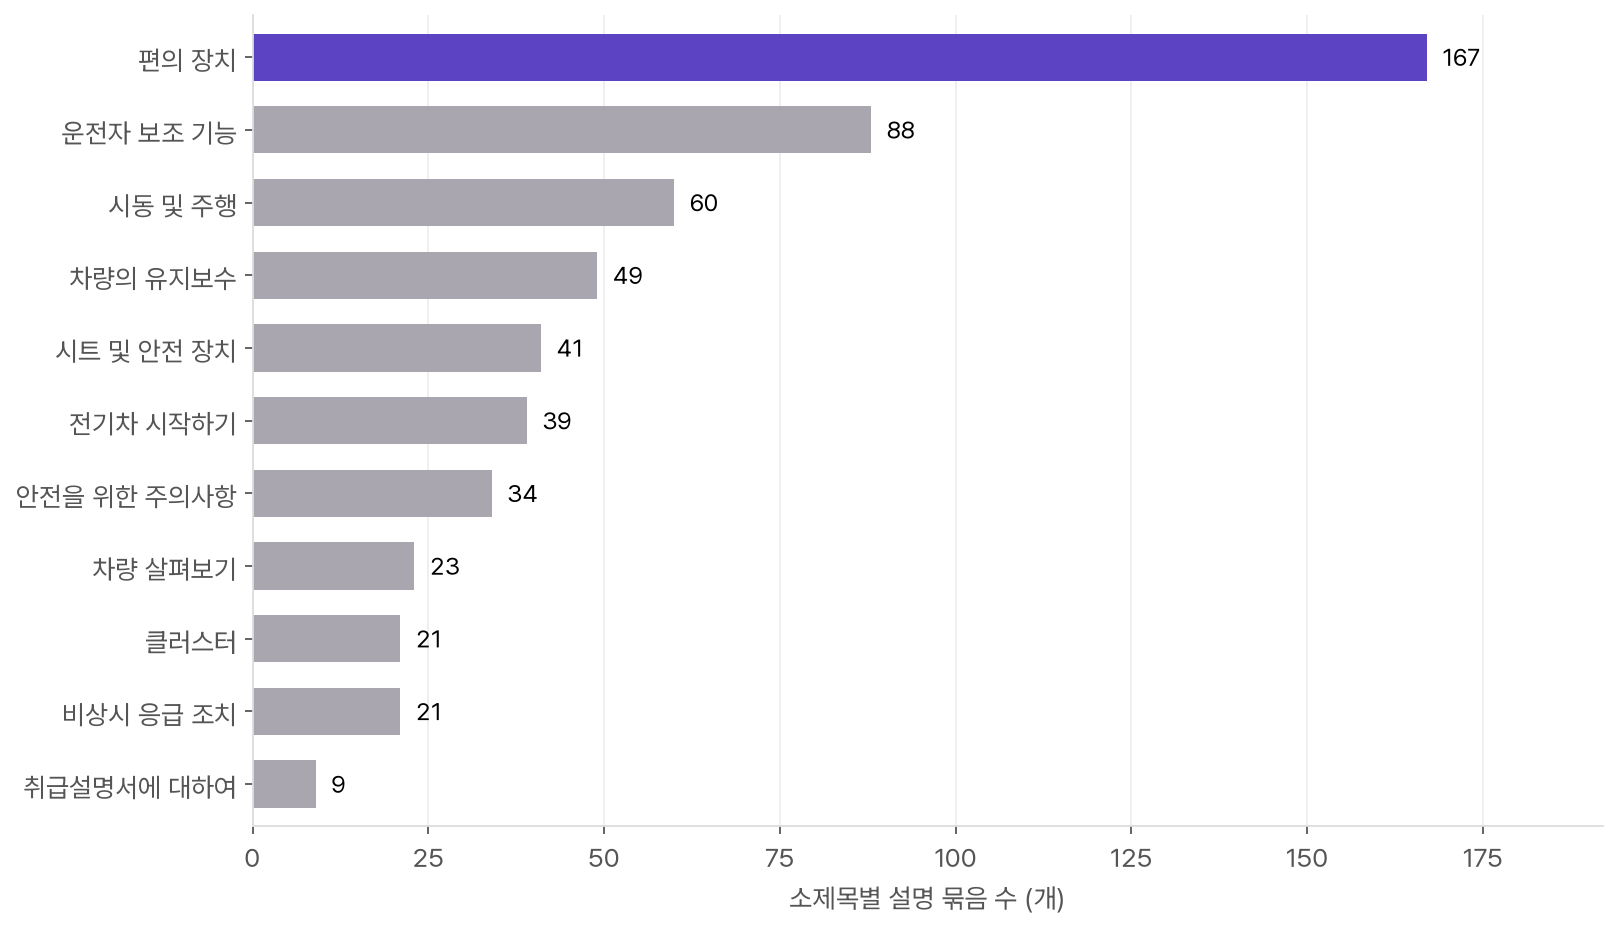

In [ ]:
fig = chart_chapters(sections)
display(fig)
plt.close(fig)

## 2. 검색 자료 10개 중 약 3개는 그림 설명입니다
회색 막대는 본문에서 나눈 글, 보라색 막대는 그림에 붙인 설명입니다.

검색용 조각 2,338개는 본문에서 나눈 글 1,670개와 그림 설명 668개로 구성됩니다. 그림 설명도 검색 대상에 들어갑니다.

예를 들어 버튼 위치를 물으면 관련 그림 설명을 찾고, 연결된 원본 그림을 답변에 보여줄 수 있습니다. 다만 지금은 그림 자체의 모양이 아니라 붙어 있는 글로 검색합니다. 668개 중 666개는 그림 주변의 글을 가져온 설명이라, 그림을 정확히 설명하는지도 따로 확인해야 합니다.

```python
counts = chunks['chunk_type'].value_counts()
ratio = counts.div(counts.sum()).mul(100)
counts.plot.barh(xlabel='검색 청크 수 (개)')
```

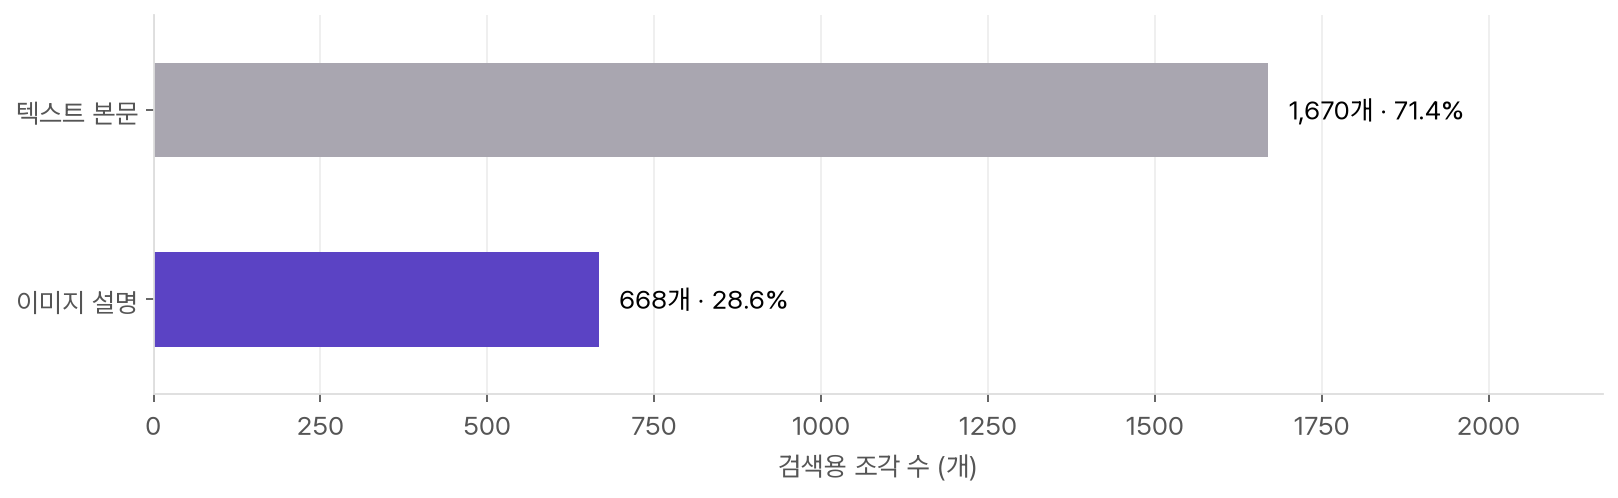

In [ ]:
fig = chart_types(chunks)
display(fig)
plt.close(fig)

## 3. 검색할 글은 최대 400자로 잘라 두었습니다
가로축은 글 조각의 길이, 세로축은 그 길이에 해당하는 조각 수입니다. 막대가 높을수록 그 길이의 조각이 많습니다.

본문에서 나눈 글 조각은 모두 400자 이내입니다. 길이순으로 줄 세웠을 때 가운데 값은 290자예요. 이것을 중앙값이라고 합니다.

짧게 나누면 필요한 부분을 골라 찾을 수 있습니다. 하지만 너무 짧으면 앞뒤 설명이 부족할 수 있어요. 50자보다 짧은 72개는 제목이나 경고 문구만 남은 것은 아닌지 살펴볼 대상입니다. 실제 답변을 만들 때는 찾은 조각의 전체 설명도 함께 가져옵니다.

```python
lengths = audit['body_length']
lengths.describe()
lengths.plot.hist(bins=range(0, 451, 50))
# 구간은 왼쪽 포함·오른쪽 제외, 마지막 구간은 양 끝 포함
# 400자 청크는 400–450 구간에 포함
```

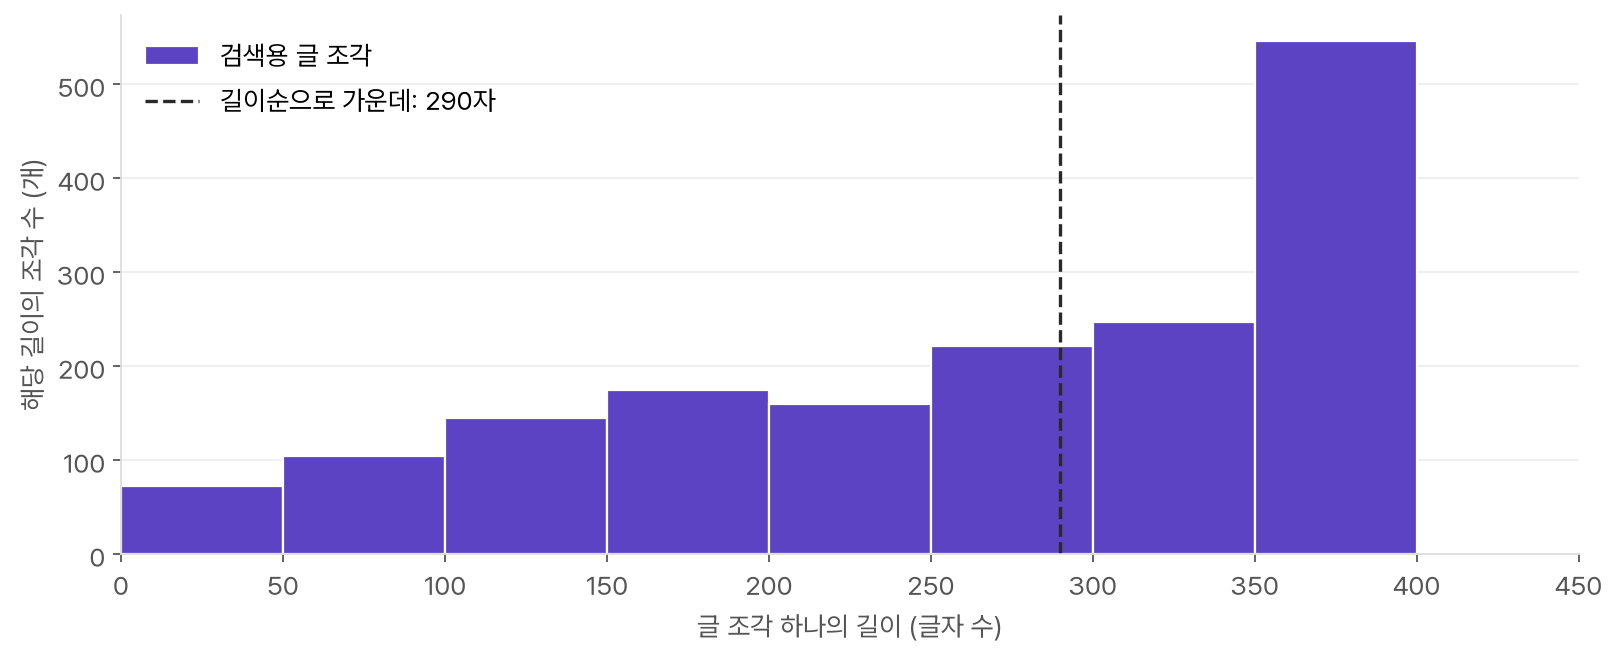

In [ ]:
fig = chart_children(audit)
display(fig)
plt.close(fig)

## 4. 전체 설명을 가져오면 읽을 양이 크게 늘기도 합니다
위 그래프는 왼쪽일수록 짧은 설명, 오른쪽일수록 긴 설명입니다. 아래 상자와 점은 같은 자료를 간단히 요약한 그림입니다.

설명 묶음을 길이순으로 줄 세우면 가운데 값은 약 392자입니다. 그런데 가장 긴 설명은 10,357자예요. 일부 긴 설명 때문에 평균은 약 761자로 올라갑니다.

그래서 검색 결과가 5개라고 읽을 양도 항상 비슷한 것은 아닙니다. 짧은 설명 5개와 긴 설명 5개는 분량이 크게 달라요. 챗봇은 같은 설명을 두 번 가져오지 않도록 하고, 한 번에 읽을 전체 설명의 양에도 제한을 둡니다.

```python
sections['body_chars'] = sections['full_text'].str.len()
lengths = sections['body_chars']
lengths.describe()
lengths.plot.hist(bins=range(0, 11001, 500))
plt.figure()
lengths.plot.box(vert=False)
```

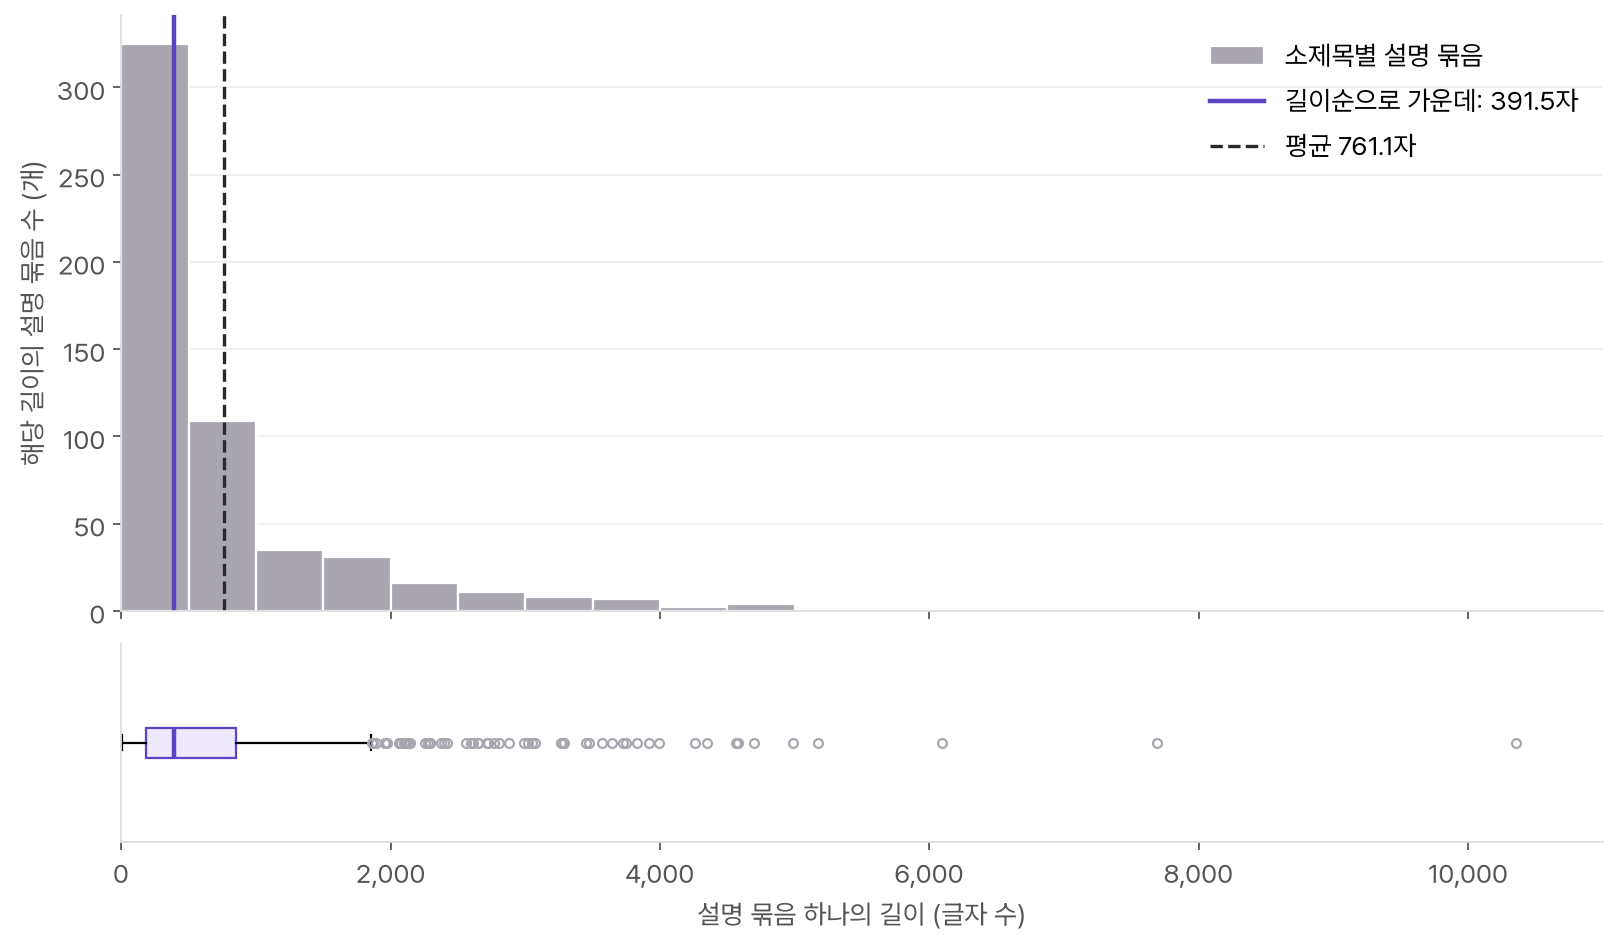

In [ ]:
fig = chart_parents(sections)
display(fig)
plt.close(fig)